In [9]:
#1. Data Loading & Preparation

import pandas as pd
import numpy as np

X = pd.read_csv("data_cleaned_engineered_input.csv")
y = pd.read_csv("data_cleaned_engineered_target.csv")

y = y.values.ravel()

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
#2. Model 1 — Linear Model (Baseline)

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

print("Ridge RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("Ridge R2:", r2_score(y_test, y_pred_ridge))

Ridge RMSE: 0.26675845450863794
Ridge R2: 0.7647521061379683


In [11]:
#3. Model 2 — Tree-Based Ensemble

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RF RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("RF R2:", r2_score(y_test, y_pred_rf))

RF RMSE: 0.15401217169967082
RF R2: 0.9215849455555426


In [12]:
#4. Model 3 — Neural Network (Deep Learning)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(32, activation='relu'),

    Dense(1)  # regression output
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

y_pred_nn = model.predict(X_test_scaled)

print("NN RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_nn)))
print("NN R2:", r2_score(y_test, y_pred_nn))

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 10.8100 - mae: 2.4603 - val_loss: 1.8635 - val_mae: 0.9467
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.3100 - mae: 1.1831 - val_loss: 0.7754 - val_mae: 0.6059
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6617 - mae: 1.0219 - val_loss: 0.6795 - val_mae: 0.5853
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.3549 - mae: 0.9200 - val_loss: 0.6185 - val_mae: 0.5679
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2111 - mae: 0.8719 - val_loss: 0.6334 - val_mae: 0.5909
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.0525 - mae: 0.8135 - val_loss: 0.6802 - val_mae: 0.6667
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.9257 - mae: 0.7645 - val_loss: 0.5902 - val_mae: 0.5973
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8305 - mae: 0.7289 - val_loss: 0.4703 - val_mae: 0.5115
Epoch 9/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7697

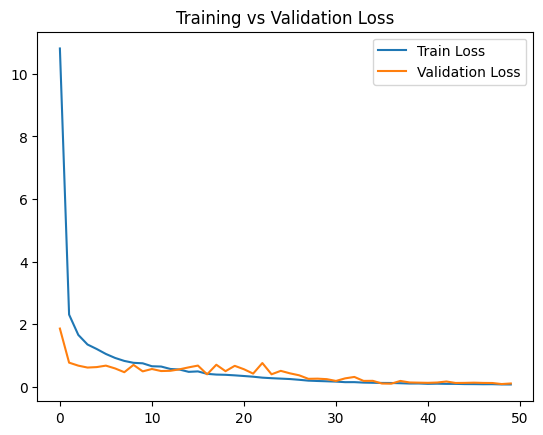

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()
